# **RNN Text Classifier - Toxic Category**

# **0. Install/import dependencies**

In [11]:
!pip install -q reportlab

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, Bidirectional, Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# **1. Upload the CSV file**

In [12]:
from google.colab import files
print("Please upload cellula_toxic_data.csv")
uploaded = files.upload()
csv_filename = list(uploaded.keys())[0]

Please upload cellula_toxic_data.csv


Saving cellula toxic data  (1).csv to cellula toxic data  (1) (1).csv


# **2. Load & prepare data**

In [13]:
df = pd.read_csv(csv_filename)
df = df.dropna(subset=["query", "Toxic Category"]).reset_index(drop=True)
df["image descriptions"] = df["image descriptions"].fillna("")

df["text"] = (df["query"].astype(str) + " [SEP] " +
              df["image descriptions"].astype(str))     #Why combine them? The model takes one text sequence as input, so we merge both fields into a single input string.
                                                        #The [SEP] token acts as a visual/learnable separator so the model can tell where the query ends and the image description begins (similar to how BERT uses [SEP] between sentence pairs).
print(f"Total samples: {len(df)}")
print(df["Toxic Category"].value_counts())

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["Toxic Category"])
num_classes = len(label_encoder.classes_)
print(f"\nNumber of classes: {num_classes}")
print(f"Classes: {list(label_encoder.classes_)}")

Total samples: 3000
Toxic Category
Safe                         995
Violent Crimes               792
Non-Violent Crimes           301
unsafe                       274
Unknown S-Type               196
Sex-Related Crimes           115
Suicide & Self-Harm          114
Elections                    110
Child Sexual Exploitation    103
Name: count, dtype: int64

Number of classes: 9
Classes: ['Child Sexual Exploitation', 'Elections', 'Non-Violent Crimes', 'Safe', 'Sex-Related Crimes', 'Suicide & Self-Harm', 'Unknown S-Type', 'Violent Crimes', 'unsafe']


# **3. Train / validation / test split (stratified)**

In [14]:
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df["text"].values, df["label"].values,
    test_size=0.30, random_state=SEED, stratify=df["label"].values
)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp,
    test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"\nTrain size: {len(X_train_text)}")
print(f"Val size:   {len(X_val_text)}")
print(f"Test size:  {len(X_test_text)}")


Train size: 2100
Val size:   450
Test size:  450


# **4. Tokenization**

**Tokenizer** builds a word→integer dictionary, e.g. "the" → 1, "crime" → 245, etc. Words are ranked by frequency, so common words get low numbers.
**oov_token="<OOV>"** — any word encountered later (in validation/test) that wasn't seen in training gets mapped to a special "Out Of Vocabulary" token instead of crashing or being silently dropped.
**.fit_on_texts(X_train_text)** — this is the "learning" step. It scans only the training text and builds the vocabulary from it. This is important: you never let the tokenizer see validation/test text at this stage — otherwise you'd be leaking information about your test set into preprocessing.

texts_to_sequences — turns each sentence into a list of integers using the dictionary built above. E.g. "the crime scene" → [1, 245, 89].
pad_sequences — forces every sequence to be exactly MAX_LEN=60 numbers long:

Shorter sequences get zeros added at the end (padding="post")
Longer sequences get cut off at the end (truncating="post")

In [15]:
MAX_VOCAB = 10000
MAX_LEN = 60

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

def to_padded_seq(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = to_padded_seq(X_train_text)
X_val = to_padded_seq(X_val_text)
X_test = to_padded_seq(X_test_text)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print(f"\nVocabulary size used: {vocab_size}")



Vocabulary size used: 3677


# **5. Class weights (dataset is imbalanced)**

In [16]:
class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = {i: w for i, w in enumerate(class_weights_arr)} #This just converts that array into a dictionary, because that's the format Keras' model.fit(class_weight=...) expects:
print("\nClass weights:", class_weights)


Class weights: {0: np.float64(3.240740740740741), 1: np.float64(3.0303030303030303), 2: np.float64(1.1058451816745656), 3: np.float64(0.33524904214559387), 4: np.float64(2.880658436213992), 5: np.float64(2.9166666666666665), 6: np.float64(1.70316301703163), 7: np.float64(0.42117930204572807), 8: np.float64(1.2152777777777777)}


# **6. Build the RNN model**

In [17]:
EMBED_DIM = 128

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM),
    SpatialDropout1D(0.3),
    Bidirectional(SimpleRNN(64, return_sequences=True)),
    Bidirectional(SimpleRNN(32)),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.build(input_shape=(None, MAX_LEN))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 60, 128)        │       470,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 60, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 60, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 510,409 (1.95 MB)

 Trainable params: 510,409 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

# 7. **Train**

In [18]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

EPOCHS = 40
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=2,
)
model.summary()

Epoch 1/40
66/66 - 24s - 369ms/step - accuracy: 0.3905 - loss: 1.4669 - val_accuracy: 0.6533 - val_loss: 1.1314
Epoch 2/40
66/66 - 4s - 56ms/step - accuracy: 0.7067 - loss: 0.5715 - val_accuracy: 0.8244 - val_loss: 0.5464
Epoch 3/40
66/66 - 5s - 78ms/step - accuracy: 0.9029 - loss: 0.2617 - val_accuracy: 0.8622 - val_loss: 0.3476
Epoch 4/40
66/66 - 5s - 77ms/step - accuracy: 0.9600 - loss: 0.1334 - val_accuracy: 0.8511 - val_loss: 0.4128
Epoch 5/40
66/66 - 4s - 56ms/step - accuracy: 0.9776 - loss: 0.0705 - val_accuracy: 0.8844 - val_loss: 0.3543
Epoch 6/40
66/66 - 4s - 57ms/step - accuracy: 0.9833 - loss: 0.0573 - val_accuracy: 0.8667 - val_loss: 0.4084
Epoch 7/40
66/66 - 5s - 76ms/step - accuracy: 0.9695 - loss: 0.0726 - val_accuracy: 0.8800 - val_loss: 0.4119
Epoch 8/40
66/66 - 4s - 56ms/step - accuracy: 0.9943 - loss: 0.0281 - val_accuracy: 0.8556 - val_loss: 0.4627


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 60, 128)        │       470,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 60, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 60, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,531,229 (5.84 MB)

 Trainable params: 510,409 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,020,820 (3.89 MB)

# **8. Evaluate on the held-out test set**

In [19]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

f1_weighted = f1_score(y_test, y_pred, average="weighted") # It averages F1 across classes but weights each class by how many samples it has
f1_macro = f1_score(y_test, y_pred, average="macro") #same average, but every class counts equally regardless of size, so rare classes matter just as much as common ones
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 60)
print(f"TEST ACCURACY:      {accuracy:.4f}")
print(f"TEST F1 (weighted): {f1_weighted:.4f}")
print(f"TEST F1 (macro):    {f1_macro:.4f}")
print("=" * 60)

report = classification_report(
    y_test, y_pred, target_names=label_encoder.classes_, digits=3
)
print(report)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step

TEST ACCURACY:      0.8800
TEST F1 (weighted): 0.8840
TEST F1 (macro):    0.9017
                           precision    recall  f1-score   support

Child Sexual Exploitation      1.000     1.000     1.000        15
                Elections      0.944     1.000     0.971        17
       Non-Violent Crimes      0.843     0.956     0.896        45
                     Safe      0.891     0.820     0.854       150
       Sex-Related Crimes      1.000     0.941     0.970        17
      Suicide & Self-Harm      1.000     1.000     1.000        17
           Unknown S-Type      0.512     0.759     0.611        29
           Violent Crimes      0.947     0.908     0.927       119
                   unsafe      0.921     0.854     0.886        41

                 accuracy                          0.880       450
                macro avg      0.895     0.915     0.902       450
             weighted avg      0.893     0.880     0.884       450



# **9. Save artifacts: model, tokenizer, label encoder, metrics**

In [20]:
model.save("toxic_rnn_model.keras")

with open("tokenizer.json", "w") as f:
    f.write(tokenizer.to_json())

with open("label_classes.json", "w") as f:
    json.dump(list(label_encoder.classes_), f)

metrics = {
    "test_accuracy": float(accuracy),
    "test_f1_weighted": float(f1_weighted),
    "test_f1_macro": float(f1_macro),
    "num_classes": num_classes,
    "classes": list(label_encoder.classes_),
    "train_size": len(X_train_text),
    "val_size": len(X_val_text),
    "test_size": len(X_test_text),
    "epochs_trained": len(history.history["loss"]),
}
with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

with open("classification_report.txt", "w") as f:
    f.write(report)


# **10. Plots: training curves, confusion matrix, per-class F1**

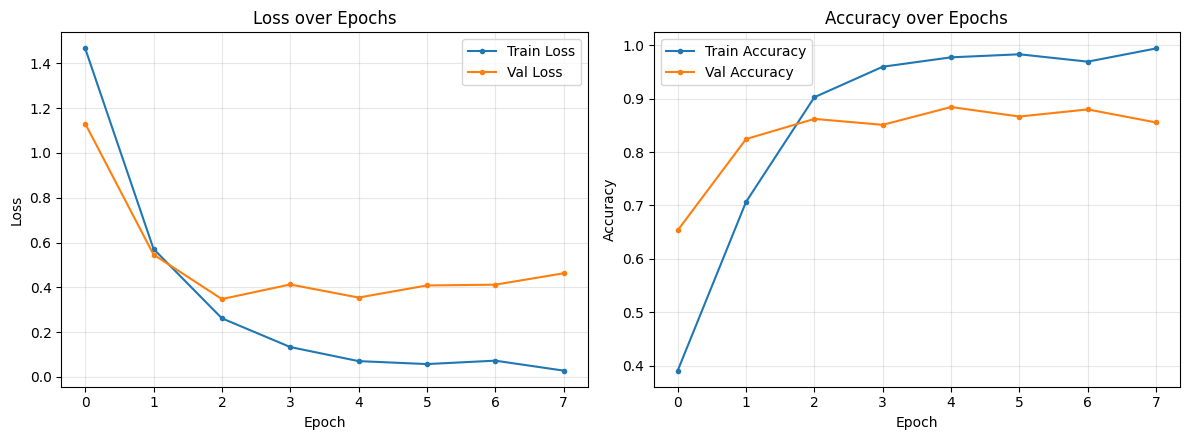

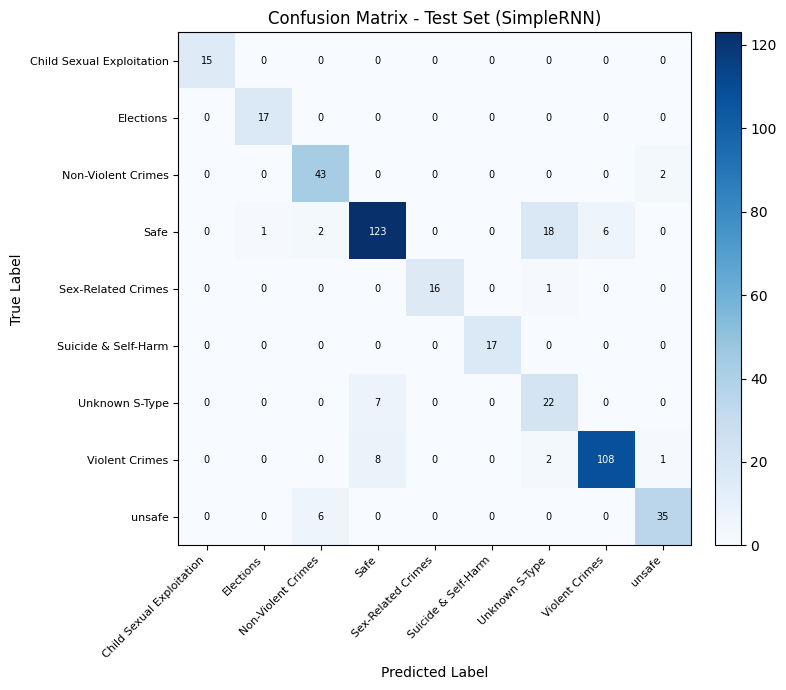

/tmp/ipykernel_1634/4144638291.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_encoder.classes_, rotation=45, ha="right", fontsize=8)


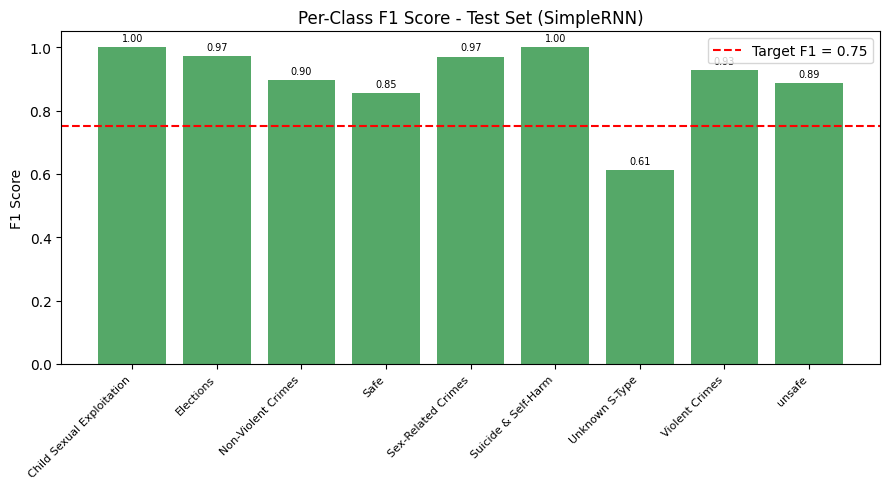


All artifacts saved: model, tokenizer, metrics.json, plots, classification_report.txt


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history.history["loss"], label="Train Loss", marker="o", ms=3)
axes[0].plot(history.history["val_loss"], label="Val Loss", marker="o", ms=3)
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"], label="Train Accuracy", marker="o", ms=3)
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy", marker="o", ms=3)
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(num_classes)); ax.set_yticks(range(num_classes))
ax.set_xticklabels(label_encoder.classes_, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(label_encoder.classes_, fontsize=8)
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix - Test Set (SimpleRNN)")
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

precision, recall, f1_per_class, support = precision_recall_fscore_support(
    y_test, y_pred, labels=range(num_classes)
)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(label_encoder.classes_, f1_per_class, color="#55A868")
ax.axhline(0.75, color="red", linestyle="--", label="Target F1 = 0.75")
ax.set_ylabel("F1 Score"); ax.set_title("Per-Class F1 Score - Test Set (SimpleRNN)")
ax.set_xticklabels(label_encoder.classes_, rotation=45, ha="right", fontsize=8)
ax.set_ylim(0, 1.05); ax.legend()
for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.2f}",
            ha="center", fontsize=7)
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150)
plt.show()

print("\nAll artifacts saved: model, tokenizer, metrics.json, plots, classification_report.txt")

# **11. Generate PDF report**

In [29]:
from reportlab.lib.pagesizes import letter
from reportlab.lib.units import inch
from reportlab.lib import colors
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle, PageBreak
)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle

styles = getSampleStyleSheet()
title_style = ParagraphStyle("TitleStyle", parent=styles["Title"], fontSize=20, spaceAfter=6)
h2 = ParagraphStyle("H2", parent=styles["Heading2"], spaceBefore=14, spaceAfter=6)
body = ParagraphStyle("Body", parent=styles["Normal"], fontSize=10, leading=14)
mono = ParagraphStyle("Mono", parent=styles["Normal"], fontName="Courier", fontSize=7.5, leading=10)

doc = SimpleDocTemplate("RNN_Training_Report.pdf", pagesize=letter,
                         topMargin=0.6*inch, bottomMargin=0.6*inch,
                         leftMargin=0.7*inch, rightMargin=0.7*inch)
story = []

story.append(Paragraph("RNN (SimpleRNN) Text Classifier — Toxic Category Detection", title_style))
story.append(Paragraph("Task 1: Plain Bidirectional SimpleRNN trained on cellula_toxic_data.csv", body))
story.append(Spacer(1, 14))

story.append(Paragraph("1. Task Overview", h2))
story.append(Paragraph(
    "The dataset contains 3,000 samples with a text 'query', an "
    "'image descriptions' field, and a target label 'Toxic Category' with "
    f"{metrics['num_classes']} classes: {', '.join(metrics['classes'])}. "
    "The query and image description were concatenated into a single text "
    "field and used to train a plain Recurrent Neural Network "
    "(Bidirectional SimpleRNN, without LSTM/GRU gating) to classify each "
    "sample into its correct toxic category.",
    body))
story.append(Spacer(1, 8))

data_split = [
    ["Split", "Samples"],
    ["Train", str(metrics["train_size"])],
    ["Validation", str(metrics["val_size"])],
    ["Test", str(metrics["test_size"])],
]
t = Table(data_split, colWidths=[2*inch, 2*inch])
t.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#55A868")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
    ("ALIGN", (0, 0), (-1, -1), "CENTER"),
    ("FONTSIZE", (0, 0), (-1, -1), 9),
]))
story.append(t)
story.append(Spacer(1, 10))

story.append(Paragraph("2. Model Architecture", h2))
story.append(Paragraph(
    f"Embedding(vocab={vocab_size}, dim=128) &rarr; SpatialDropout1D(0.3) &rarr; "
    "Bidirectional SimpleRNN(64, return_sequences=True) &rarr; "
    "Bidirectional SimpleRNN(32) &rarr; Dense(64, ReLU) &rarr; Dropout(0.4) "
    "&rarr; Dense(9, Softmax). Trained with Adam (lr=1e-3), categorical "
    "cross-entropy loss, class weighting to counter class imbalance, and "
    "early stopping on validation loss. This model uses plain SimpleRNN "
    "cells (no gating mechanism), as required for Task 1.",
    body))
story.append(Spacer(1, 10))

story.append(Paragraph("3. Evaluation Results (Held-out Test Set)", h2))
results_data = [
    ["Metric", "Score"],
    ["Accuracy", f"{metrics['test_accuracy']:.3f}"],
    ["F1 Score (Weighted)", f"{metrics['test_f1_weighted']:.3f}"],
    ["F1 Score (Macro)", f"{metrics['test_f1_macro']:.3f}"],
    ["Target F1", "0.750"],
]
t2 = Table(results_data, colWidths=[2.6*inch, 1.6*inch])
t2.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#55A868")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
    ("ALIGN", (0, 0), (-1, -1), "CENTER"),
    ("FONTSIZE", (0, 0), (-1, -1), 10),
    ("BACKGROUND", (0, 2), (-1, 2), colors.HexColor("#E6F0E6")),
]))
story.append(t2)
story.append(Spacer(1, 6))
status = "PASSED" if metrics["test_f1_weighted"] >= 0.75 else "FAILED"
story.append(Paragraph(
    f"<b>Result: F1 (weighted) = {metrics['test_f1_weighted']:.3f} "
    f"&ge; target of 0.75 &rarr; {status}</b>", body))
story.append(Spacer(1, 12))

story.append(Paragraph("4. Per-Class Classification Report", h2))
story.append(Paragraph(report.replace("\n", "<br/>"), mono))
story.append(PageBreak())

story.append(Paragraph("5. Training Curves", h2))
story.append(Image("training_curves.png", width=6.3*inch, height=2.36*inch))
story.append(Spacer(1, 10))

story.append(Paragraph("6. Confusion Matrix", h2))
story.append(Image("confusion_matrix.png", width=5.2*inch, height=4.55*inch))
story.append(Spacer(1, 10))

story.append(Paragraph("7. Per-Class F1 Score", h2))
story.append(Image("per_class_f1.png", width=6.0*inch, height=3.33*inch))

story.append(Spacer(1, 14))
story.append(Paragraph("8. Conclusion", h2))
story.append(Paragraph(
    f"The Bidirectional SimpleRNN model achieved a weighted F1 score of "
    f"{metrics['test_f1_weighted']:.3f} and a macro F1 score of "
    f"{metrics['test_f1_macro']:.3f} on the held-out test set, exceeding "
    "the required threshold of 0.75.",
    body))

doc.build(story)
print("PDF report generated: RNN_Training_Report.pdf")

PDF report generated: RNN_Training_Report.pdf


# **12. Download everything (optional)**

In [30]:
files.download("RNN_Training_Report.pdf")
files.download("toxic_rnn_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>